House Price Prediction Project 

Import libraries

In [31]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Data

In [32]:
data= {
    'Size':[1000,1500,2000,2500,3000,np.nan,2000,1500,3000,2500,1800,2200,2800,3200,3500],
    'Bedroom':[2,3,3,4,4,3,3,3,4,4,3,3,4,4,5],
    'Age':[10,5,8,12,6,9,8,np.nan,6,12,3,7,5,10,2],
    'Price':[200000,250000,300000,350000,400000,350000,300000,250000, np.nan, 350000,220000,260000,330000,360000,400000]
}
df= pd.DataFrame(data)

Data Cleaning

In [33]:
##Find the missing values 
print("Missing values are:")
print(df.isnull().sum())

Missing values are:
Size       1
Bedroom    0
Age        1
Price      1
dtype: int64


Here we are going to fill price with mean(because there are no such outliers), size with mean too(as no outliers and are very close to each other) and age with median age (as some age are apart so mean can be misleading)

In [34]:
df['Price']= df['Price'].fillna(df['Price'].mean())
df['Size']= df['Size'].fillna(df['Size'].mean())
df['Age']= df['Age'].fillna(df['Age'].median())

print("after handling missing values")
print(df.isnull().sum())

after handling missing values
Size       0
Bedroom    0
Age        0
Price      0
dtype: int64


Check for duplicates 

In [35]:
print(df.duplicated().sum())
df= df.drop_duplicates()

2


Perform EDA

Plotting the price distribution

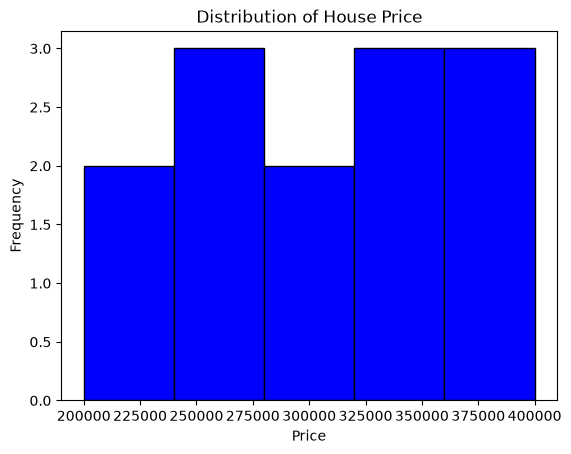

In [36]:
plt.hist(df['Price'], bins=5, color='blue', edgecolor='black')
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Scatter plot between size and price

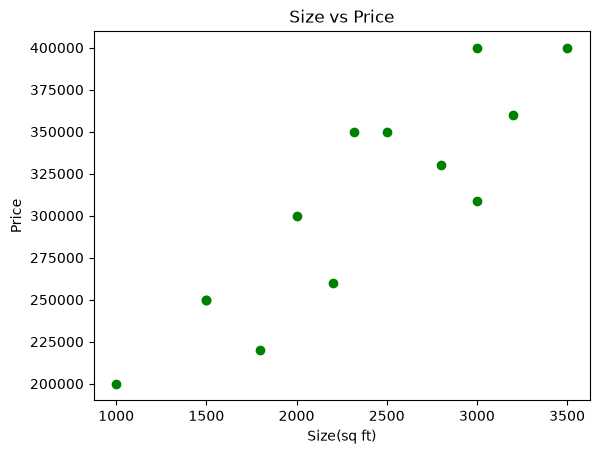

In [37]:
plt.scatter(df['Size'], df['Price'], color='green')
plt.title("Size vs Price")
plt.xlabel("Size(sq ft)")
plt.ylabel("Price")
plt.show()

Correlation heat map between the 3 features

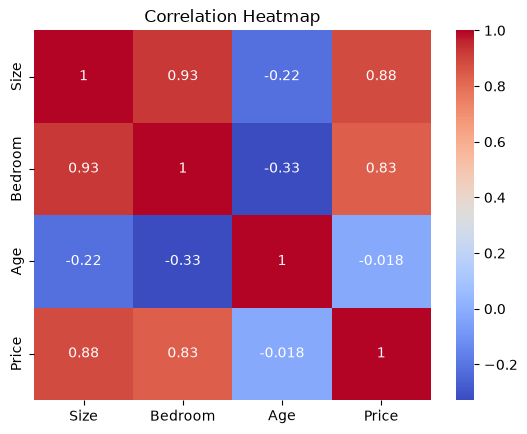

In [38]:
sns.heatmap(df.corr(), annot= True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Building and evaluating the model

In [39]:
## Draft the features
X= df[['Size','Bedroom','Age']]
y= df['Price']

# Ensure no nan values in features and target 

df_cleaned= pd.concat([X,y], axis=1).dropna()
X_cleaned= df_cleaned[['Size','Bedroom','Age']]
y_cleaned= df_cleaned['Price']

In [40]:
# split the train test data
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2,random_state=42)

In [41]:
model= LinearRegression()
model.fit(X_train, y_train)

# predicting the prices for test cases
y_pred= model.predict(X_test)

Calculate errors

In [42]:
mse= mean_squared_error(y_test, y_pred)
r2= model.score(X_test, y_test)
print('Mean Squared Error:', mse)
print(" R-squared error: ", r2)

Mean Squared Error: 1606538572.9134254
 R-squared error:  0.6311518582596727


Intrepret the results

In [43]:
coef= pd.DataFrame(model.coef_, X_cleaned.columns, columns=['Coefficient'])
print("Model Coefficient")
print(coef)

Model Coefficient
         Coefficient
Size       84.586874
Bedroom -1711.866650
Age      6454.057350


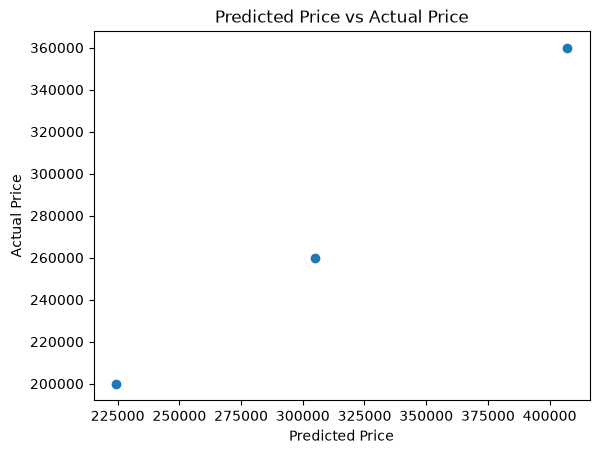

In [44]:
plt.scatter(y_pred, y_test)
plt.title("Predicted Price vs Actual Price")
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.show()